In [99]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**OBJECTIVE :Given a Bank customer, can we build a classifier that can determine whether they will leave or not using Neural networks?**

In [0]:
%tensorflow_version 2.x

**Import and Read Data**

In [0]:
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [0]:
bankchurn_data = pd.read_csv("/content/drive/My Drive/GreatLakes/NeuralNetwork/Project1/Churn_Modelling.csv")

In [103]:
bankchurn_data.info()
#14 columns and 10000 observations

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
RowNumber          10000 non-null int64
CustomerId         10000 non-null int64
Surname            10000 non-null object
CreditScore        10000 non-null int64
Geography          10000 non-null object
Gender             10000 non-null object
Age                10000 non-null int64
Tenure             10000 non-null int64
Balance            10000 non-null float64
NumOfProducts      10000 non-null int64
HasCrCard          10000 non-null int64
IsActiveMember     10000 non-null int64
EstimatedSalary    10000 non-null float64
Exited             10000 non-null int64
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [104]:
bankchurn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [105]:
bankchurn_data.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [0]:
bankchurn_data.drop(columns=['RowNumber', 'CustomerId','Surname'], axis=1, inplace=True, errors='ignore')
#Rownumber and CustomerId are unique across
#Surname not adding value to model so removing it

**Data Exploration**

In [107]:
bankchurn_data.describe().T
#11 numeric features are describe here

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


In [108]:
bankchurn_data.describe(include='object').T
#3 non numeric features are described here
# Total 2932 unique surnames
# Total 3 geographies - Need to find out 3 geographies

,count,unique,top,freq
Geography,10000,3,France,5014
Gender,10000,2,Male,5457


In [109]:
bankchurn_data['Geography'].value_counts()
#Customers are from 'France', 'Spain','Germany' with Customer from France comprising majority group

France     5014
Germany    2509
Spain      2477
Name: Geography, dtype: int64

In [110]:
bankchurn_data['Gender'].value_counts()

Male      5457
Female    4543
Name: Gender, dtype: int64

In [111]:
bankchurn_data['Exited'].value_counts()
#80% data is from non-churned cutomers
#20% data is from churned customers
#imbalanced data set . How to ensure that neural network works well with imbalanced data

0    7963
1    2037
Name: Exited, dtype: int64

In [112]:
(bankchurn_data.duplicated()).value_counts()
#No duplicates exist

False    10000
dtype: int64

In [113]:
bankchurn_data.isna().sum()
#No missing values exist

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

**Outlier Handling**

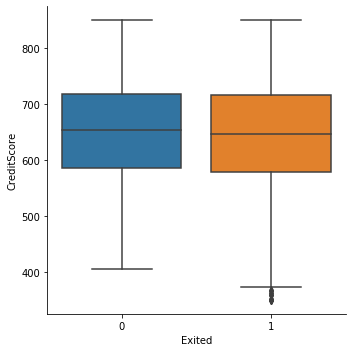

In [114]:
sns.catplot(x='Exited', y="CreditScore", kind="box", data=bankchurn_data)
#Some people with low credit score have exited. No need of handing
#Credit score similar across churned and non churned

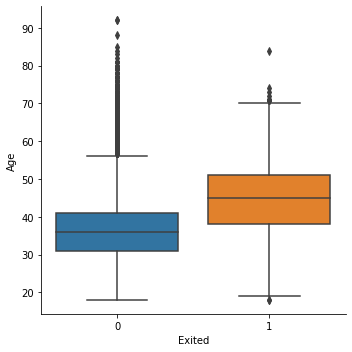

In [115]:
sns.catplot(x='Exited', y="Age", kind="box", data=bankchurn_data)
#Age shows outliers above 62 years of age till 95 years of age. Dont see any need to remove these as can be valid customer
#nor sure of replacing these
#Age of churned customers is slightly higher

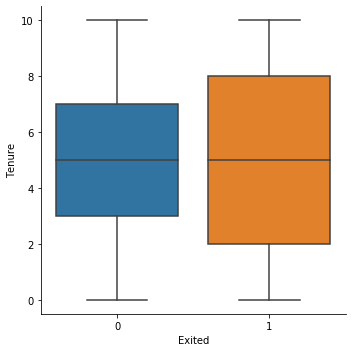

In [116]:
sns.catplot(x='Exited', y="Tenure", kind="box", data=bankchurn_data)
#Churned customers have relatively higher spread of duration
#No outliers exist

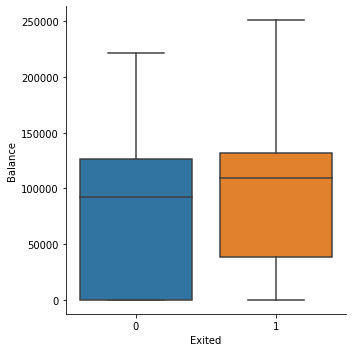

In [117]:
sns.catplot(x='Exited', y="Balance", kind="box", data=bankchurn_data)
#Churned customers have less spread of bank balance and range from 40000 to 130000 approx. No outliers exist

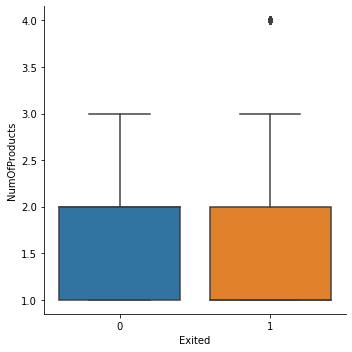

In [118]:
sns.catplot(x='Exited', y="NumOfProducts", kind="box", data=bankchurn_data)
#Similar spread across churned and unchurned customers. Not a good predictor
#Only one outlier 


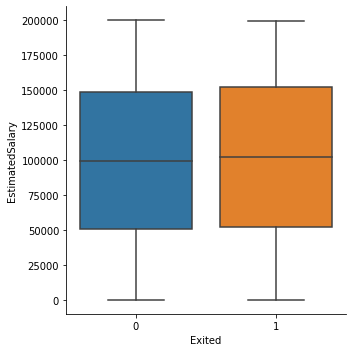

In [119]:
sns.catplot(x='Exited', y="EstimatedSalary", kind="box", data=bankchurn_data)
#No outliers and spread of salary is similar. Not a good feture for churn and nonchurn detection

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7feef08a3ba8>,
      dtype=object)

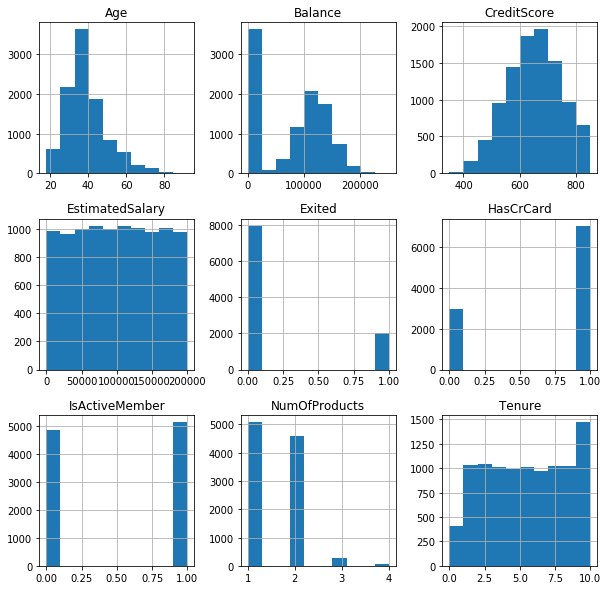

In [120]:
bankchurn_data.hist(figsize=(10,10))
#Age shows right skew
#Balance shows left skew with a large group showing 0 to 25000 balance
#CreditScore shows slight left skew
#Estimated salary is eually distributed with almost equal count(around 1000) of people having various salary brackets
#UnChurned customers are 4 times the churned


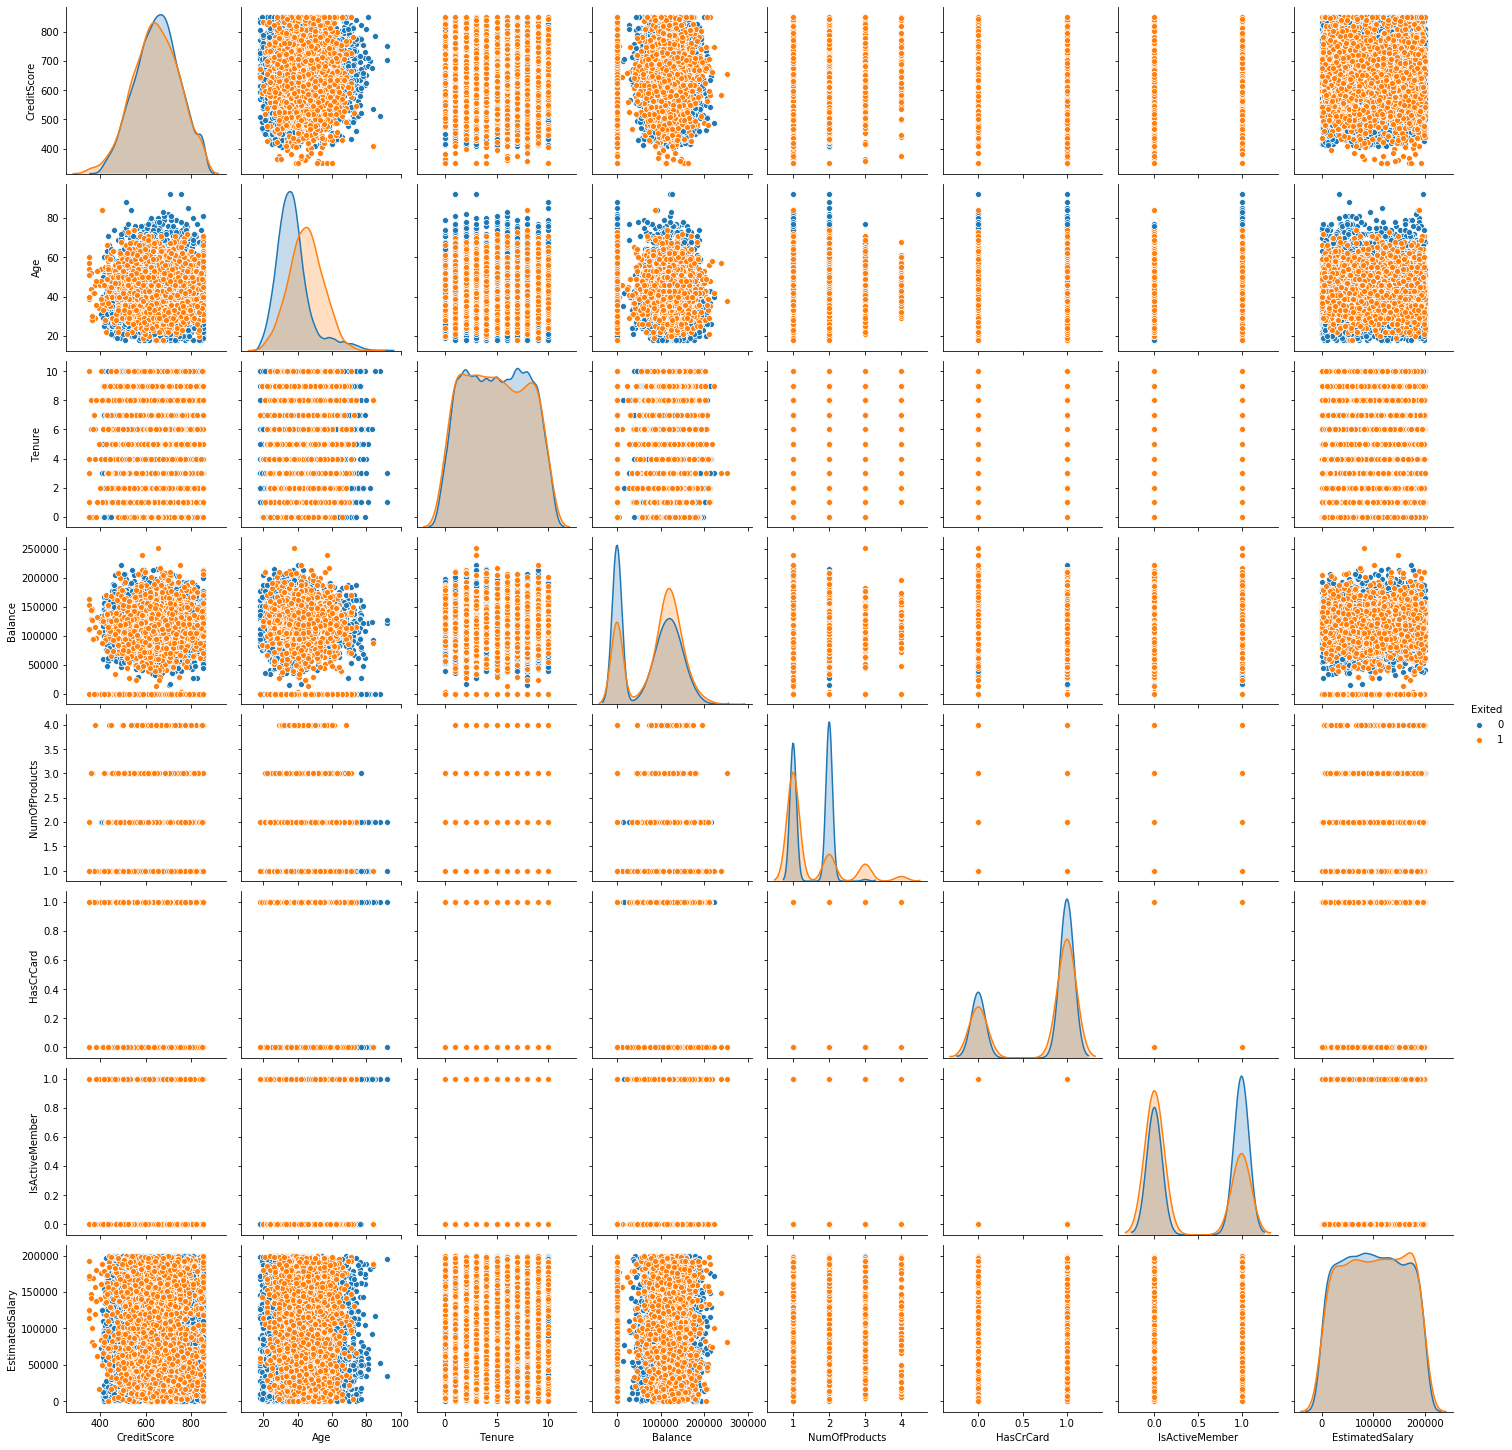

In [121]:
sns.pairplot(data=bankchurn_data, hue= 'Exited',diag_kind='kde')

In [0]:
#Diagonal KDE shows all features are poor predictors (as KDE of both the classes are overlapping so not able to clearly distinguissh 
# two classes clearly based on these features)
#
# There is no collinearity amongst features (which is good)
# Balance is showing two different peaks for boh the classes indicating presene of some clusters
# NumofProducts showing two different peaks(clusters). In addition there seem to be outliers for both the classes
# HasCard showing two different peaks correspnding to two different clusters of customers who have credit cards and who do not have
# IsActiveMember showing two different peaks correspnding to two different clusters of customers who are active and who are not

In [122]:
#Check skewness
bankchurn_data.skew(numeric_only  = True)
#If the skewness is less than -1 or greater than 1, the data are highly skewed
#There is Exited column which is skewed but the skew is not that big so ignoring it

CreditScore       -0.071607
Age                1.011320
Tenure             0.010991
Balance           -0.141109
NumOfProducts      0.745568
HasCrCard         -0.901812
IsActiveMember    -0.060437
EstimatedSalary    0.002085
Exited             1.471611
dtype: float64

In [123]:
#Distinguish the feature and target set
y_target = bankchurn_data['Exited']
#X_features =
y_target.shape

(10000,)

In [124]:
X_features = bankchurn_data.drop(columns='Exited', axis=1, errors='raise')
X_features.shape


(10000, 10)

In [0]:
#Geographical and gender are categorical data, let us covert those using one hot encoding
X_features = pd.get_dummies(X_features, drop_first=True)


In [126]:
X_features.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


In [127]:

from sklearn.model_selection import train_test_split

#Divide the data set into training and test sets ( 2.5 points)
Xtrain, Xtest, ytrain, ytest= train_test_split(X_features, y_target, test_size=0.2, random_state=7)
#Xtrain, Xtest, ytrain, ytest= train_test_split(X_features, y_target, test_size=0.3, random_state=7)
print(Xtrain.shape, ytrain.shape)

(8000, 11) (8000,)


In [128]:
print(Xtest.shape, ytest.shape)

(2000, 11) (2000,)


**Upsampling due to imbalance in dataset**

In [0]:
from imblearn.over_sampling import SMOTE

In [130]:
print("Before UpSampling, counts of label '1': {}".format(sum(ytrain==1)))
print("Before UpSampling, counts of label '0': {} \n".format(sum(ytrain==0)))

Before UpSampling, counts of label '1': 1626
Before UpSampling, counts of label '0': 6374 



In [131]:
sm = SMOTE(sampling_strategy = 1 ,k_neighbors = 5, random_state=1)   #Synthetic Minority Over Sampling Technique
Xtrain_res, ytrain_res = sm.fit_sample(Xtrain, ytrain.ravel())

print("After UpSampling, counts of label '1': {}".format(sum(ytrain_res==1)))
print("After UpSampling, counts of label '0': {} \n".format(sum(ytrain_res==0)))

print('After UpSampling, the shape of train_X: {}'.format(Xtrain_res.shape))
print('After UpSampling, the shape of train_y: {} \n'.format(ytrain_res.shape))

Xtrain = Xtrain_res
ytrain = ytrain_res

After UpSampling, counts of label '1': 6374
After UpSampling, counts of label '0': 6374 

After UpSampling, the shape of train_X: (12748, 11)
After UpSampling, the shape of train_y: (12748,) 



In [0]:
#Normlize the train and test data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit(Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)


**Create Base Model Of Neural Network**

1.  Initialize Sequential Graph (model)

2.  Add Input Layer  with relu activation

3. Add Batch Normalization (To increase the stability of a neural network, batch normalization normalizes the output of a previous activation layer by subtracting the batch mean and dividing by the batch standard deviation.) Try Batch Normalization first after activation and then before activation and choose option with better results - Batch Normalization before activation giving better accuracy and precision and recall of class of interest

3.   Add Hidden Layer with relu activation [Taking as average of nodes in the input layer (11 nodes) and the number of nodes in the output layer (1 node). For this case is 11+1/2 = 6]

4.drop = 0 for the base model and non zero for regularized model

5.   Add Output Layer with sigmoid activation [sigmoid is chosen because  output varies between 0 to 1]

6.   Compile the Model - OPTIMIZER ALGORITHM help us to minimize error.
Using Adam as it works well in practice and  converges very fast and the learning speed of the Model is quiet Fast and efficient and also it rectifies every problem that is faced in other optimization techniques such as vanishing 
Learning rate , slow convergence or High variance in the parameter updates which leads to fluctuating Loss function



In [0]:
def build_model(drop=0.0):
  #Sequential Model
  model = tf.keras.models.Sequential()

  #Input Layer
  model.add(tf.keras.layers.Dense(11, input_shape=(11, )))
  model.add(tf.keras.layers.BatchNormalization())
  model.add(tf.keras.layers.Activation('relu'))
  #Dropout added at the time of regularization
  model.add(tf.keras.layers.Dropout(drop))

  #Hidden layer
  #model.add(tf.keras.layers.Dense(units = 6,  activation = 'relu'))
  model.add(tf.keras.layers.Dense(6))
  model.add(tf.keras.layers.BatchNormalization())
  model.add(tf.keras.layers.Activation('relu'))
  #Dropout added at the time of regularization
  model.add(tf.keras.layers.Dropout(drop))

  #Output Layer
  model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

  #Compile the model
  model.compile(optimizer='adam', loss=tf.keras.losses.BinaryCrossentropy(), metrics=['accuracy'])
  return model

In [0]:
model = build_model()

1.**Fit the model Using batch and epochs**
*  BATCH SIZE = 10 After how many data points the weights would be updated.Total 8000 samples to be trained so 8000/10 = 800 batches
*   EPOCHS = 100 Number of times the model will be trained (within each epoch,
batch_size loop will be run)


In [136]:
history = model.fit(Xtrain, ytrain, validation_data=(Xtest, ytest), batch_size=10, epochs=100)
#Observation: Considerable improvement in performance by using batch_size and epochsMODEL 

Train on 12748 samples, validate on 2000 samples
Epoch 1/100
12748/12748 [==============================] - 3s 266us/sample - loss: 0.6330 - accuracy: 0.6508 - val_loss: 0.5626 - val_accuracy: 0.6975
Epoch 2/100
12748/12748 [==============================] - 3s 209us/sample - loss: 0.5663 - accuracy: 0.7136 - val_loss: 0.5120 - val_accuracy: 0.7500
Epoch 3/100
12748/12748 [==============================] - 3s 207us/sample - loss: 0.5305 - accuracy: 0.7405 - val_loss: 0.4776 - val_accuracy: 0.7710
Epoch 4/100
12748/12748 [==============================] - 3s 207us/sample - loss: 0.5141 - accuracy: 0.7521 - val_loss: 0.4615 - val_accuracy: 0.7950
Epoch 5/100
12748/12748 [==============================] - 3s 210us/sample - loss: 0.5026 - accuracy: 0.7599 - val_loss: 0.4467 - val_accuracy: 0.7995
Epoch 6/100
12748/12748 [==============================] - 3s 207us/sample - loss: 0.4948 - accuracy: 0.7618 - val_loss: 0.4429 - val_accuracy: 0.8000
Epoch 7/100
12748/12748 [====================

**Function For plotting train and validation accuracy against epochs**

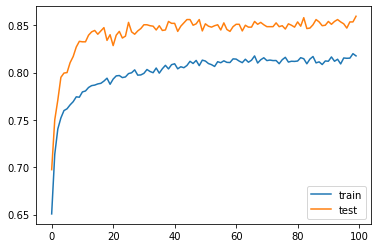

In [137]:
def plot(history): # plot history
  pyplot.plot(history.history['accuracy'], label='train')
  pyplot.plot(history.history['val_accuracy'], label='test')
  pyplot.legend()
  pyplot.show()

plot(history)

**Evaluation And Prediction Function**

In [0]:
def evaluate_model(Xtrain, ytrain, Xtest, ytest):
  from  sklearn.metrics import accuracy_score, confusion_matrix, classification_report
  print("EVALUATION OF TRAIN :\n")
  model.evaluate(Xtrain,  ytrain, verbose=2)
  print("\nEVALUATION OF TEST :\n")
  model.evaluate(Xtest,  ytest, verbose=2)

  #Predict the results using 0.5 as a threshold
  #numpy array probabilities - The predicted probability is taken as the likelihood of the observation belonging to class 1,
  probabilities = model.predict_proba(Xtest)
  #If probability is more than 0.5 then class belongs to 1 else it belongs to 0
  testPredictions = probabilities>0.5#np.where(probabilities>0.5, 1, 0)
  print("\nTOP 10 PREDICTIONS ARE :\n",testPredictions[0:10])#Top 10 predictions
  
  #Print the Accuracy score and confusion matrix
  print("\nACCURACY SCORE IS :\n",accuracy_score(ytest, testPredictions))
  #Precision tells out of predicted churned customers how many are correctly predicted (more precision means we missed less) 
  #On the other side, recall tell us of total prediction, how many were correctly predicted.

  print("\nCONFUSION MATRIX FOR ACTUAL vs PREDICTED IS :\n",confusion_matrix(ytest, testPredictions))
  
   #Print complete classification report
  print("\nCLASSIFICATION REPORT IS :\n")
  print(classification_report(ytest, testPredictions))

In [139]:
print("BASE MODEL: \n")
evaluate_model(Xtrain, ytrain, Xtest, ytest)
#Precision and recall of class of interest i.e. churn is very less

BASE MODEL: 

EVALUATION OF TRAIN :

12748/12748 - 0s - loss: 0.3685 - accuracy: 0.8396

EVALUATION OF TEST :

2000/2000 - 0s - loss: 0.3497 - accuracy: 0.8595

TOP 10 PREDICTIONS ARE :
 [[False]
 [False]
 [False]
 [ True]
 [False]
 [False]
 [False]
 [False]
 [False]
 [ True]]

ACCURACY SCORE IS :
 0.8595

CONFUSION MATRIX FOR ACTUAL vs PREDICTED IS :
 [[1518   71]
 [ 210  201]]

CLASSIFICATION REPORT IS :

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1589
           1       0.74      0.49      0.59       411

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



**Cross Validation Score**

In [95]:
#fit our model to the traing data using KerasClassifier
from sklearn.model_selection import cross_val_score

classifier = tf.keras.wrappers.scikit_learn.KerasClassifier(build_fn = build_model, batch_size = 10, epochs = 100 )
accuracies = cross_val_score(estimator = classifier, X = Xtrain, y = ytrain, cv = 3, n_jobs = -1)
mean = accuracies.mean()
std = accuracies.std()

Variance is  0.1086822921411315


In [96]:
print("Mean is :",mean)
print("\nStd is :", std)
#variance is low 

Mean is : 0.7650560736656189

variance is : 0.1086822921411315


**Regularize Parameters**

**1. Dropout - Randomly drop neurons so that other neurons are forced to learn more**

Train on 12748 samples, validate on 2000 samples
Epoch 1/100
12748/12748 [==============================] - 3s 273us/sample - loss: 0.7049 - accuracy: 0.5789 - val_loss: 0.5803 - val_accuracy: 0.7435
Epoch 2/100
12748/12748 [==============================] - 3s 216us/sample - loss: 0.6079 - accuracy: 0.6799 - val_loss: 0.5431 - val_accuracy: 0.7455
Epoch 3/100
12748/12748 [==============================] - 3s 219us/sample - loss: 0.5889 - accuracy: 0.7039 - val_loss: 0.5300 - val_accuracy: 0.7565
Epoch 4/100
12748/12748 [==============================] - 3s 218us/sample - loss: 0.5794 - accuracy: 0.7111 - val_loss: 0.5211 - val_accuracy: 0.7665
Epoch 5/100
12748/12748 [==============================] - 3s 213us/sample - loss: 0.5745 - accuracy: 0.7125 - val_loss: 0.5095 - val_accuracy: 0.7725
Epoch 6/100
12748/12748 [==============================] - 3s 216us/sample - loss: 0.5689 - accuracy: 0.7183 - val_loss: 0.4984 - val_accuracy: 0.7910
Epoch 7/100
12748/12748 [====================

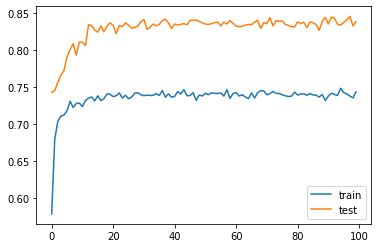

Dropout MODEL: 

EVALUATION OF TRAIN :

12748/12748 - 0s - loss: 0.3685 - accuracy: 0.8396

EVALUATION OF TEST :

2000/2000 - 0s - loss: 0.3497 - accuracy: 0.8595

TOP 10 PREDICTIONS ARE :
 [[False]
 [False]
 [False]
 [ True]
 [False]
 [False]
 [False]
 [False]
 [False]
 [ True]]

ACCURACY SCORE IS :
 0.8595

CONFUSION MATRIX FOR ACTUAL vs PREDICTED IS :
 [[1518   71]
 [ 210  201]]

CLASSIFICATION REPORT IS :

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1589
           1       0.74      0.49      0.59       411

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [151]:
model_reg = build_model(0.20)
history = model_reg.fit(Xtrain, ytrain, validation_data=(Xtest, ytest), batch_size=10, epochs=100)
plot(history)

print("Dropout MODEL: \n")
evaluate_model(Xtrain, ytrain, Xtest, ytest)

#OBSERVATION: No major improvement was observed as our Neural network is not very dense and neurons also not very large

**Observations**

1. All the features are poor predictions in differntiating the churn and non churn
2. There is class imbalance(80% of classes are for unchurned customers), that is why despite the features being poor predictors, through base model of Neural Network able to achieve accuracy of 86
3. In Base Model, Adam and SGD optimizers gave similar performance in both train and test but Adam converged faster
4. Train Test split of 80-20 as well as 70-30 was tried. There was no change in accuracy. However, there was change in top 10 predictions. in 80:20 3 out of top 10 were shown as true for churn. While in 70-30 2 out of top 10 were true. By having slightly more data in train set, we want to have little more train data and we increase the probability of inclusion of class of interest(which is less in number) to be included in train data
5. Batch Normalization before activation giving better accuracy and precision and recall
6. Upsampling of churned dataset was done for training. After upsampling, precision and recall of class of interest changed from (0.81,0.45) to (0.73,0.47). Higher recall means TP>FN better . Thus Number of actual churned identified as nonchurned are less indicating better model
7.Dropout was done - No improvement achieved when we tried 0.10 and 0.20 because base model is not very complex

**Conclusions**
1. Dropped 'RowNumber', 'CustomerId' from original dataset as these were unique for all users. 'Surname' was removed as it is not adding value to the model 
2. The entire dataset was split into Feature and target set. Target was 'Exited'
3. Data was analysed for outliers. Age had many outliers for customers above 60 but could not find any criterio to remove those . Those seem to be valid customers. CreditScore had negative outliers but the count was less
4. Divided the data set into training and test sets [80:20 ratio]
5. Normalize the train and test data by using StandardScaler  
6. Base model 
  a. Had input, hidden(1) and output layer
  b. Added batch normalization
  c. Activation was 'Relu' for inner layers and 'Sigmoid' for outer layer
  PERFORMANCE - Train accuracy 0.8176 Test accuracy - 0.8595, Precision of class 1 - 0.74, Recall - 0.49

  7. Final Model  
  Performance Train Accuracy Test Accuracy , Precision(class 1) , Recall(class1)

  8. Drop out had not much impact on simple neural network
  9. Predicted the results using 0.5 as a threshold (Top 10 predictions had 2 cases of churn i.e 20% churn.This is matching with churn rate as per original dataset)
   8. Final Model with 0.20 drop out
   Test Accuracy Score: 0.85
            Confusion Matrix:[[1518   71]
                              [ 210  201]]
            TN = 1518
            FP = 71
            FN = 210
            TP = 201

            Precision: 0.74
            Recall: 0.49

            Precision and recall was low as features are poor predictorrs 
            and data was imbalanced (imbalance was artificially removed though)
     